## 1. Introdução ao dataset

O presente estudo realiza uma análise exploratória do conjunto de dados "Air Quality UCI". Este dataset é de grande relevância para a área de ciências ambientais e aprendizado de máquina, pois contém registros detalhados da qualidade do ar de uma cidade metropolitana italiana, coletados entre março de 2004 e fevereiro de 2005.

Os dados foram capturados por um dispositivo multisensor que media, em intervalos horários, a concentração de diversos poluentes atmosféricos, como monóxido de carbono (CO), benzeno (C6H6) e óxidos de nitrogênio (NOx), além de registrar condições meteorológicas como temperatura e umidade.

A análise deste conjunto de dados visa identificar padrões, distribuições e correlações entre as variáveis, fornecendo insights valiosos sobre a dinâmica da poluição do ar em um ambiente urbano. O entendimento dessas características é o primeiro passo para a construção de modelos preditivos e para a avaliação do impacto ambiental na saúde pública.

## 2. Descrição dataset

#### 2.1 Importando bibliotecas

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys

#### 2.2 Carregando dataset

In [10]:
sys.path.append('..')

# Carrega o dataset 
df = pd.read_csv("../database/air_quality_uci.csv", sep=";", decimal=",", parse_dates=[['Date', 'Time']], na_values=-200)  

# Remoção de duas colunas vazias que estão no final do dataset
df = df.iloc[:, :-2]

# Exibir as 5 primeiras linhas para verificar se foi carregado corretamente
print(f"Dataset shape: {df.shape}")
print("Cabeçalho do DataFrame:")
print(df.head())

Dataset shape: (9471, 14)
Cabeçalho do DataFrame:
             Date_Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  10/03/2004 18.00.00     2.6       1360.0     150.0      11.9   
1  10/03/2004 19.00.00     2.0       1292.0     112.0       9.4   
2  10/03/2004 20.00.00     2.2       1402.0      88.0       9.0   
3  10/03/2004 21.00.00     2.2       1376.0      80.0       9.2   
4  10/03/2004 22.00.00     1.6       1272.0      51.0       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0         1046.0    166.0        1056.0    113.0        1692.0       1268.0   
1          955.0    103.0        1174.0     92.0        1559.0        972.0   
2          939.0    131.0        1140.0    114.0        1555.0       1074.0   
3          948.0    172.0        1092.0    122.0        1584.0       1203.0   
4          836.0    131.0        1205.0    116.0        1490.0       1110.0   

      T    RH      AH  
0  13.6  48.9  0.7578  
1  13.3  47.7  0.7255  


C:\Users\picol\AppData\Local\Temp\ipykernel_27076\2253380503.py:4: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv("../database/air_quality_uci.csv", sep=";", decimal=",", parse_dates=[['Date', 'Time']], na_values=-200)
C:\Users\picol\AppData\Local\Temp\ipykernel_27076\2253380503.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("../database/air_quality_uci.csv", sep=";", decimal=",", parse_dates=[['Date', 'Time']], na_values=-200)


#### 2.3 Obter número de instâncias e variáveis

In [11]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

print("Dimensões:", df.shape)  # linhas e colunas
print("Valores nulos por coluna:\n", df.isna().sum())


Dimensões: (9471, 14)
Valores nulos por coluna:
 Date_Time           0
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64


#### 2.4 Listagem de variáveis

In [12]:
# Lista variáveis, tipos de dados e contagem de valores não nulos
print("Dataset Information:")
print("=" * 80)
print(df.info())
print("\n" + "=" * 80)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date_Time      9471 non-null   object 
 1   CO(GT)         7674 non-null   float64
 2   PT08.S1(CO)    8991 non-null   float64
 3   NMHC(GT)       914 non-null    float64
 4   C6H6(GT)       8991 non-null   float64
 5   PT08.S2(NMHC)  8991 non-null   float64
 6   NOx(GT)        7718 non-null   float64
 7   PT08.S3(NOx)   8991 non-null   float64
 8   NO2(GT)        7715 non-null   float64
 9   PT08.S4(NO2)   8991 non-null   float64
 10  PT08.S5(O3)    8991 non-null   float64
 11  T              8991 non-null   float64
 12  RH             8991 non-null   float64
 13  AH             8991 non-null   float64
dtypes: float64(13), object(1)
memory usage: 1.0+ MB
None



#### 2.5 Contagem de valores nulos por variáveis

In [13]:
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Missing Values:
Date_Time           0
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

Total missing values: 18183


# 3. Estátisticas univariadas incondicionais

#### 3.1 Calculo da media
<span style="font-size: 15px;">A média, ou valor médio, é a medida de tendência central mais comum. No contexto do nosso dataset, ela nos dará um valor "típico" para cada sensor e medição ao longo de todo o período de coleta. </span>

In [ ]:
# Cálculo da média para cada variável numérica
mean_values = df.mean(numeric_only=True)
print("Média para cada variável:")
print(mean_values)

Média para cada variável:
CO(GT)              2.152750
PT08.S1(CO)      1099.833166
NMHC(GT)          218.811816
C6H6(GT)           10.083105
PT08.S2(NMHC)     939.153376
NOx(GT)           246.896735
PT08.S3(NOx)      835.493605
NO2(GT)           113.091251
PT08.S4(NO2)     1456.264598
PT08.S5(O3)      1022.906128
T                  18.317829
RH                 49.234201
AH                  1.025530
dtype: float64


#### 3.2 Calculo do desvio padrao
<span style="font-size: 15px;">O desvio padrão nos diz o quão espalhados ou variáveis os dados são em torno dessa média. Um desvio padrão baixo significa que a maioria dos valores está muito próxima da média. Os dados são consistentes e previsíveis. Um desvio padrão alto significa que os valores estão muito espalhados. Há uma grande variação nas medições, com muitos valores longe da média. 
Para o nosso dataset, o desvio padrão vai nos ajudar a entender a volatilidade de cada poluente e condição climática.</span>

In [15]:
#Cálculo do desvio padrão para cada variável numérica
std_dev_values = df.std(numeric_only=True)
print("\nDesvio padrão para cada variável:")
print(std_dev_values)


Desvio padrão para cada variável:
CO(GT)             1.453252
PT08.S1(CO)      217.080037
NMHC(GT)         204.459921
C6H6(GT)           7.449820
PT08.S2(NMHC)    266.831429
NOx(GT)          212.979168
PT08.S3(NOx)     256.817320
NO2(GT)           48.370108
PT08.S4(NO2)     346.206794
PT08.S5(O3)      398.484288
T                  8.832116
RH                17.316892
AH                 0.403813
dtype: float64


#### 3.3 Calculo de skewness (Assimetria)
Enquanto a média e o desvio padrão nos dão informações sobre o centro e a dispersão, a skewness nos diz sobre a forma da distribuição.
- Skewness ≈ 0: A distribuição é quase simétrica. Os dados se espalham de maneira uniforme em ambos os lados da média. A curva parece um sino (distribuição normal).
- Skewness > 0: A distribuição tem uma "cauda" mais longa à direita. Isso significa que, embora a maioria dos valores esteja concentrada à esquerda, existem alguns valores extremamente altos que "puxam" a média para a direita.
- Skewness < 0: A distribuição tem uma "cauda" mais longa à esquerda. A maioria dos valores está concentrada à direita, mas alguns valores extremamente baixos "puxam" a média para a esquerda.
No nosso caso, a Skewness vai nos dizer, por exemplo, se os picos de poluição são mais comuns do que períodos de ar excepcionalmente limpo.

In [16]:
# Calcula a skewness para todas as colunas numéricas
skewness_values = df.skew(numeric_only=True)
print("Assimetria (Skewness) para cada variável:")
print(skewness_values)

Assimetria (Skewness) para cada variável:
CO(GT)           1.369753
PT08.S1(CO)      0.755907
NMHC(GT)         1.557017
C6H6(GT)         1.361532
PT08.S2(NMHC)    0.561566
NOx(GT)          1.715781
PT08.S3(NOx)     1.101729
NO2(GT)          0.621714
PT08.S4(NO2)     0.205389
PT08.S5(O3)      0.627864
T                0.309357
RH              -0.037928
AH               0.251388
dtype: float64


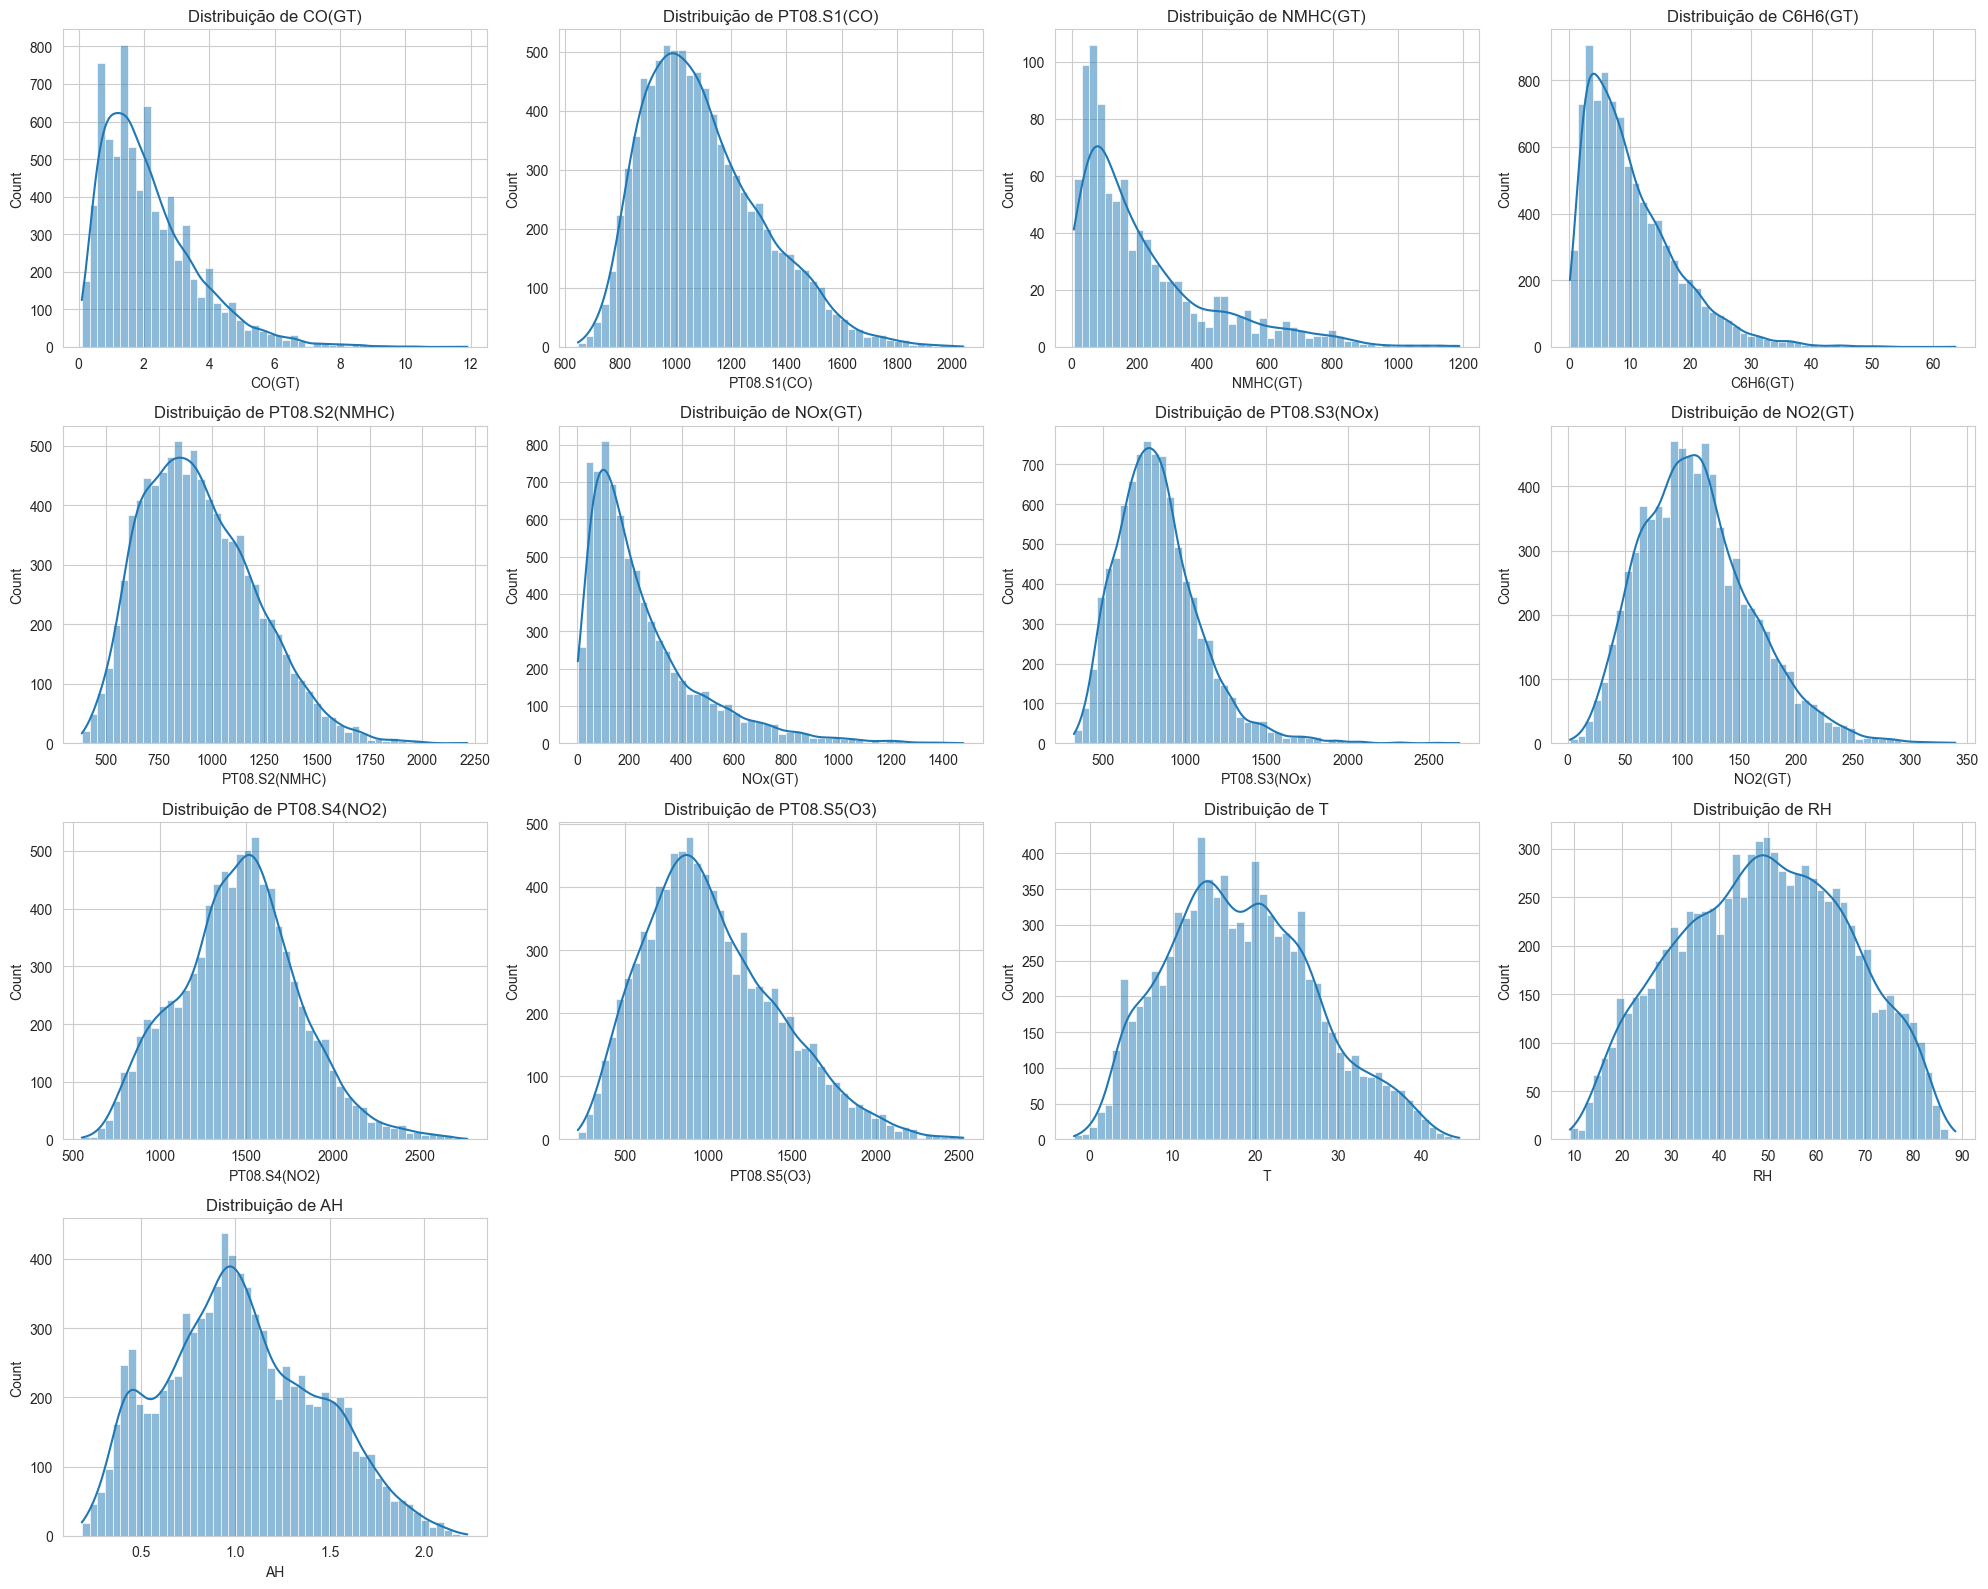

In [ ]:
# Somente colunas numéricas
numeric_cols = df.select_dtypes(include=np.number).columns

# Define o layout da grade e o tamanho total da figura
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))

# Loop para criar histogramas para cada coluna numérica
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.histplot(data=df, x=col, kde=True, bins=50, ax=ax)
    ax.set_title(f'Distribuição de {col}', fontsize=12)


# Esconde as colunas vazias
for i in range(len(numeric_cols), 16):
    axes.flatten()[i].axis('off')

# Espaçamento
plt.tight_layout()

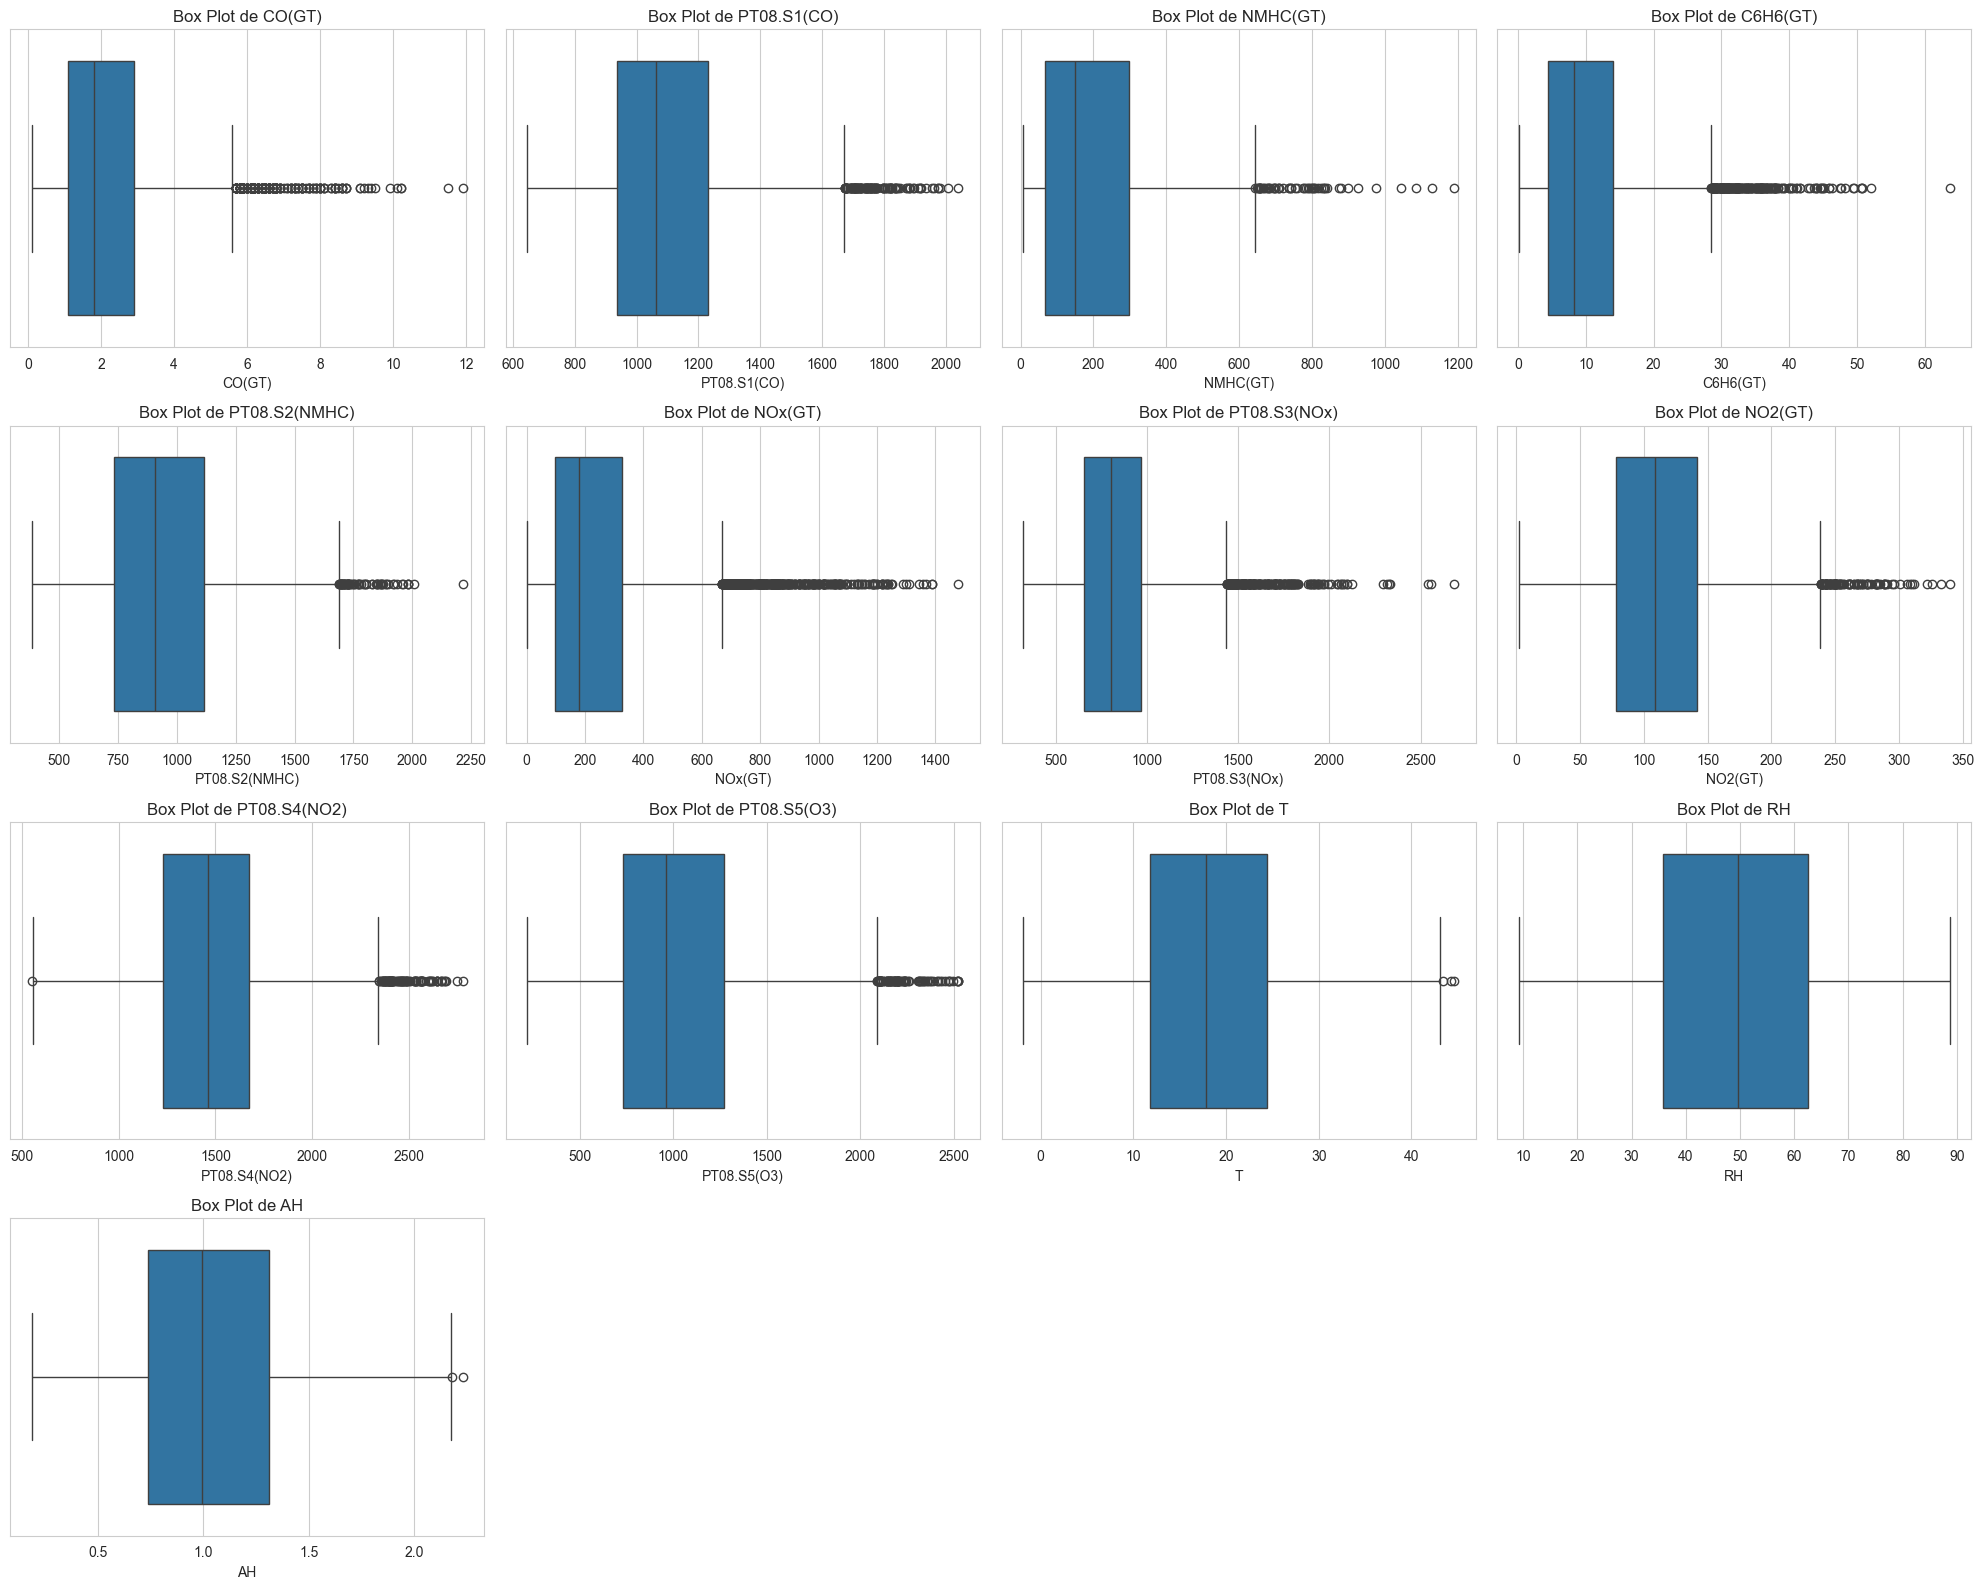

In [22]:
# Somente as colunas numéricas
numeric_cols = df.select_dtypes(include=np.number).columns

# Define o layout da grade e o tamanho total da figura
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))

# Loop para criar box plots para cada coluna numérica
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'Box Plot de {col}', fontsize=12)

# Esconde as colunas vazias
for i in range(len(numeric_cols), 16):
    axes.flatten()[i].axis('off')

# Espaçamento
plt.tight_layout()